<a href="https://colab.research.google.com/github/DhangeSakshiSanjay/Celebal_Weekly_Assignments/blob/main/week3_Sakshi_Dhange.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Week 3 Assignment - Unsupervised Learning.
Name : Sakshi Sanjay Dhange (Sanjivani COE)

# Week 3 Assignment

## Customer Intelligence / Country Segmentation using Unsupervised Learning

### Steps Performed

- Loaded the dataset
- Cleaned and preprocessed the data
- Scaled the numerical features
- Determined the optimal number of clusters
- Applied the K-Means clustering algorithm
- Evaluated clustering using the Silhouette Score
- Compared results with DBSCAN
- Visualized clusters using PCA
- Performed cluster profiling
- Summarized key observations and conclusions

In [2]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

## Import Required Libraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
plt.rcParams['figure.figsize']=(7,5)

## Load the Dataset

Upload the Country Data CSV file into Google Colab.

In [4]:
from google.colab import files
uploaded=files.upload()
file=list(uploaded.keys())[0]
df=pd.read_csv(file)
display(df.head())

Saving Country-data.csv to Country-data.csv


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 3. Dataset Overview

In [5]:
print(df.shape)
display(df.info())
display(df.describe(include='all'))

(167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
unique,167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,NaN,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,NaN,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,NaN,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,NaN,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,NaN,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000


## Data Cleaning and Preprocessing

This step prepares the data for clustering.

It includes:

- Copy the dataset
- Rename columns
- Remove duplicate rows
- Convert values to numeric
- Fill missing values with the median

This helps improve data quality and gives better clustering results.

In [6]:
# Create a copy of the dataset
df = df.copy()

# Make column names lowercase and remove extra spaces
df.columns = [col.strip().lower() for col in df.columns]
# Remove duplicate rows
df = df.drop_duplicates()
# Convert feature columns to numeric values
for col in df.columns:
    if col != "country":
        df[col] = pd.to_numeric(df[col], errors="coerce")
# Get all numeric columns
numeric_cols = [col for col in df.columns if col != "country"]
# Fill missing values with the median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
# Check for missing values
print("Missing Values:")
df.isnull().sum()
print("✓ Column names cleaned")
print("✓ Duplicate rows removed")
print("✓ Missing values handled")
print("✓ Numeric conversion completed")

Missing Values:
✓ Column names cleaned
✓ Duplicate rows removed
✓ Missing values handled
✓ Numeric conversion completed


## Exploratory Data Analysis (EDA)

EDA helps us understand the data before clustering.

A correlation heatmap is used to see how the numerical features are related to each other.

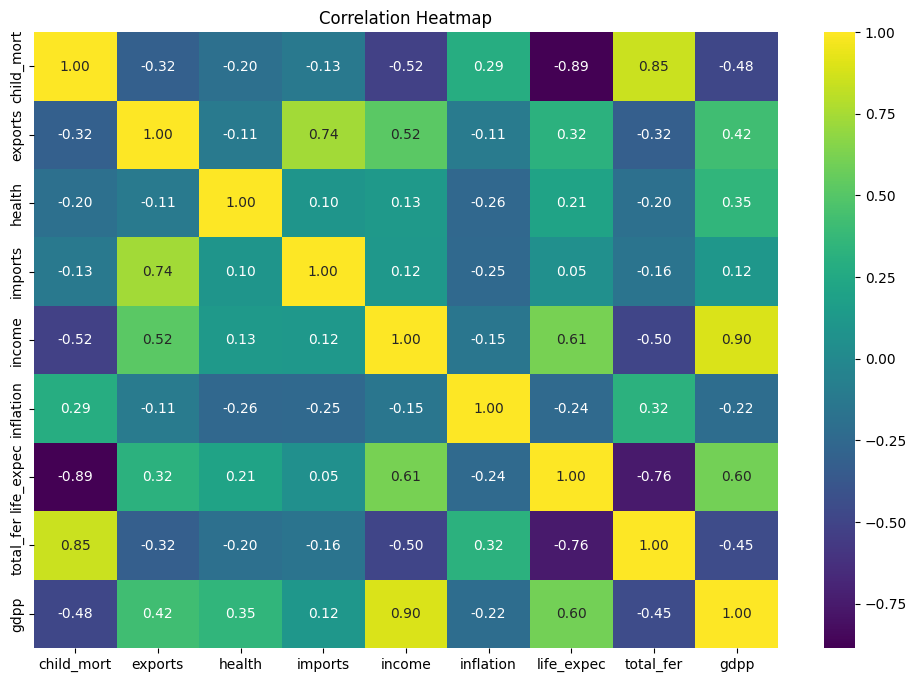

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

## Outlier Detection using Boxplots

Boxplots help identify outliers in the numerical features.

Finding outliers is important because they can affect clustering results.

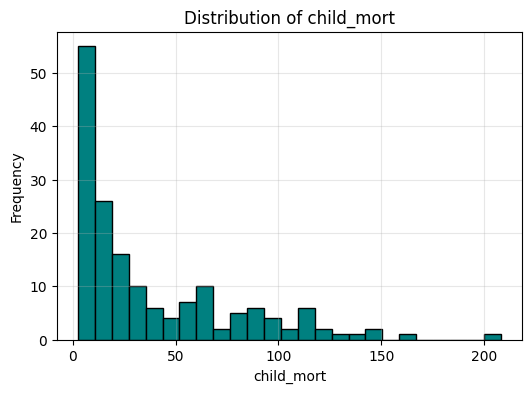

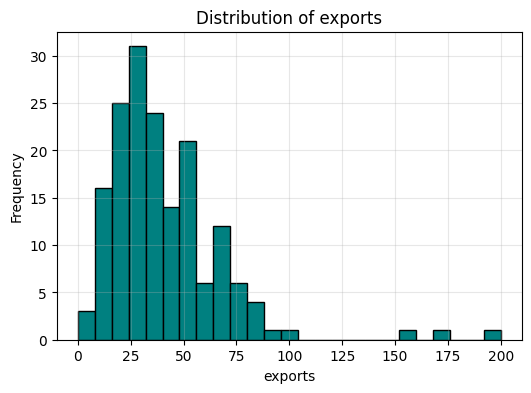

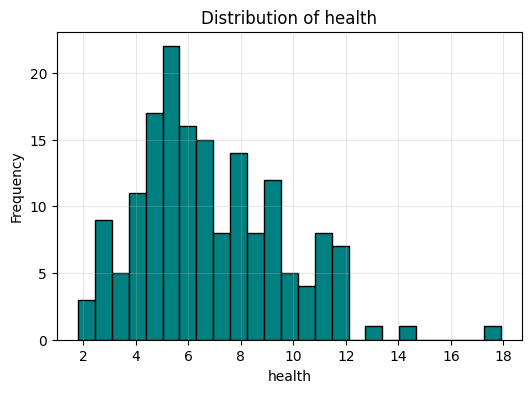

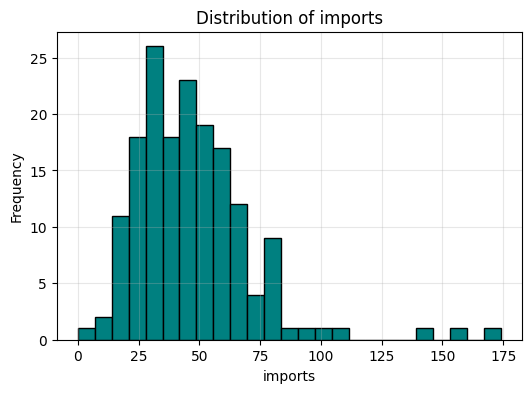

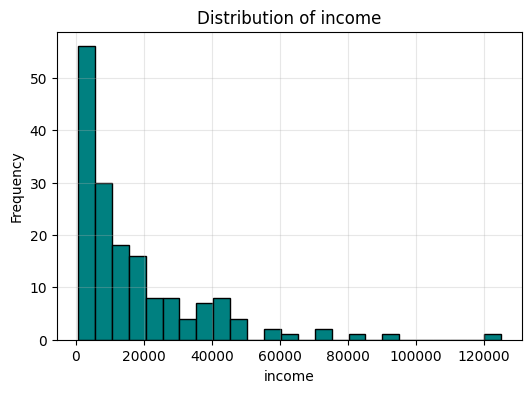

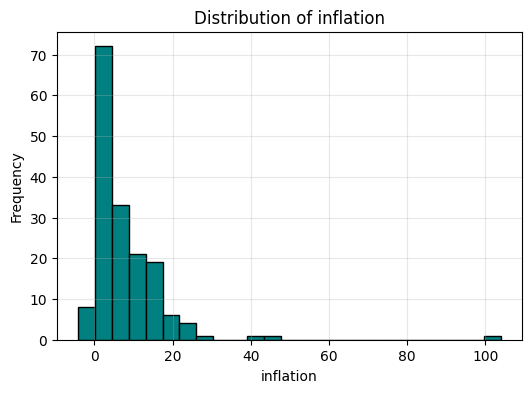

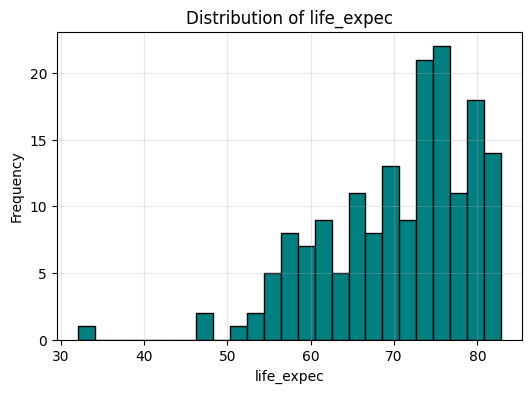

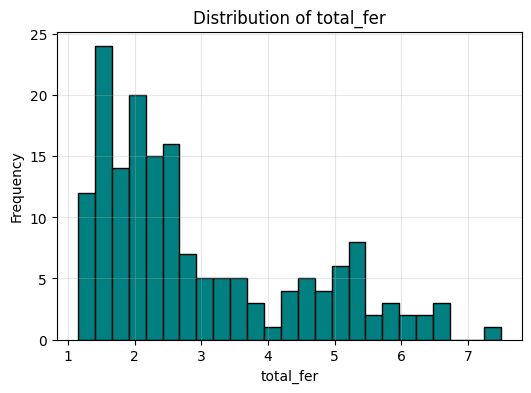

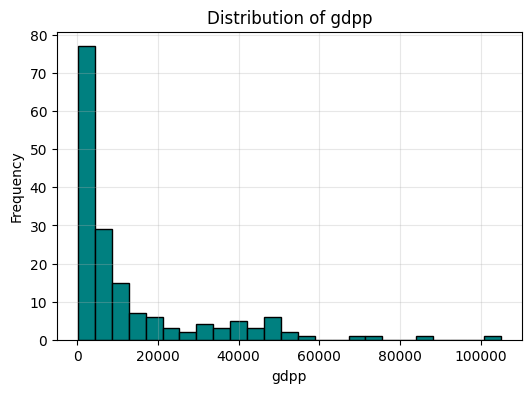

In [9]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=25, color="teal", edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

## Feature Scaling

The numerical features are standardized using StandardScaler so that each feature contributes equally during clustering.

StandardScaler scales the data with a mean of 0 and a standard deviation of 1, which helps improve clustering results.

In [10]:
X = df.drop(columns=["country"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (167, 9)


## Elbow Method

The Elbow curve bends around **k = 3**, indicating that three clusters provide the best balance between model simplicity and compactness.

The Elbow Method helps find the best number of clusters.

It calculates inertia for different values of K. The point where the curve starts to bend is chosen as the optimal number of clusters.

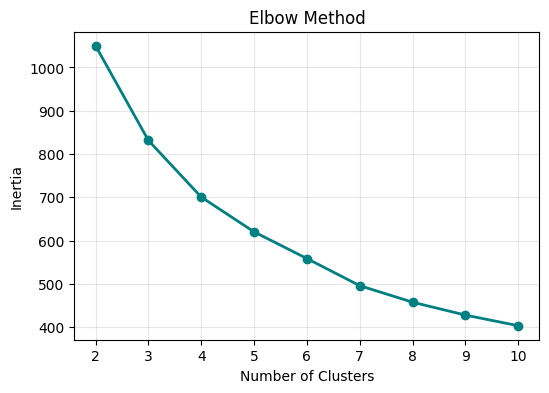

In [11]:
inertia = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(2,11), inertia, marker='o', color='teal', linewidth=2)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)
plt.show()

## Elbow Curve

The Elbow Curve shows the best number of clusters.

The bend in the graph is selected as the optimal value of K for K-Means.

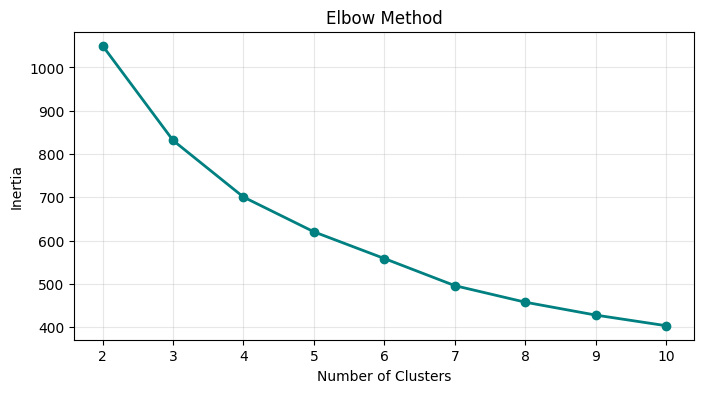

In [12]:
plt.figure(figsize=(8,4))
plt.plot(range(2,11), inertia,
         marker="o",
         color="teal",
         linewidth=2)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(alpha=0.3)
plt.show()

## K-Means Clustering

K-Means groups the countries into **3 clusters** based on similar features.

The **Silhouette Score** is used to check the clustering quality. A higher score means better clusters.

In [21]:
best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print("Silhouette Score:",
      silhouette_score(X_scaled,
                       df['kmeans_cluster']))
df[['country','kmeans_cluster']].head()


Silhouette Score: 0.28329575683463126


,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


## 9. Silhouette

The Silhouette Score measures how well countries fit within their assigned cluster.

A higher score indicates better separation between clusters.

In [16]:
print("Silhouette Score:", silhouette_score(X_scaled, kmeans.labels_))

Silhouette Score: 0.28329575683463126


## DBSCAN Clustering

DBSCAN groups countries based on data density.

It can also identify noise and outliers.

Parameters used:

- eps = 1.5
- min_samples = 5

In [19]:
# Initialize DBSCAN
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

# Predict clusters
df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

print("DBSCAN Cluster Distribution:")
print(df["dbscan_cluster"].value_counts().sort_index())


DBSCAN Cluster Distribution:
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


## Principal Component Analysis (PCA)

PCA reduces the data to two main components.

This makes it easier to visualize and understand the K-Means clusters.

In [ ]:

pca = PCA(
    n_components=2,
    random_state=42
)
X_pca = pca.fit_transform(X_scaled)
viz = pd.DataFrame({
    "PCA 1": X_pca[:,0],
    "PCA 2": X_pca[:,1],
    "Cluster": df["kmeans_cluster"]
})
viz.head()

,PCA 1,PCA 2,Cluster
0,-2.913025,0.095621,1
1,0.429911,-0.588156,2
2,-0.285225,-0.455174,2
3,-2.932423,1.695555,1
4,1.033576,0.136659,2


## PCA Cluster Visualization

The scatter plot below shows the K-Means clusters using the first two principal components (PCA).

Different colors represent different clusters, making it easy to see how countries are grouped.

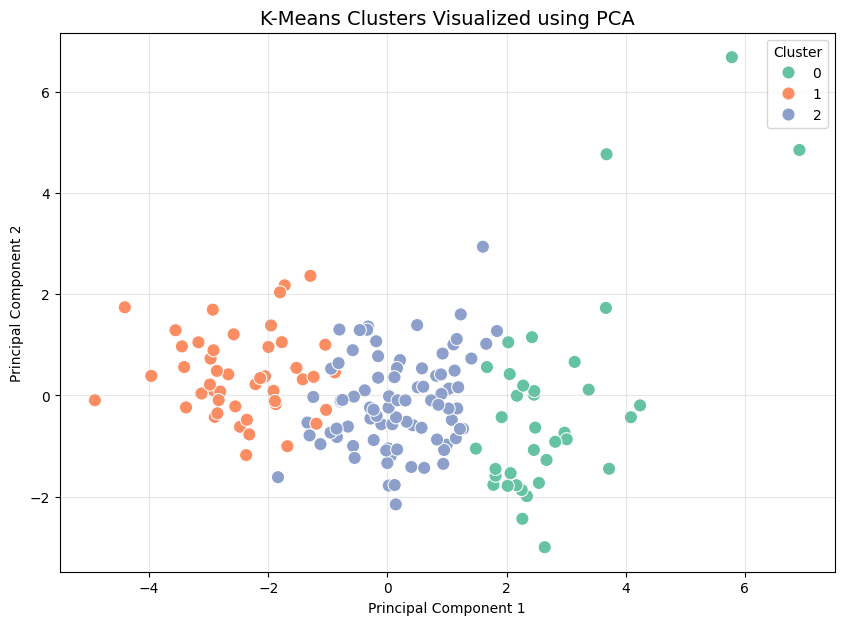

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=viz,
    x="PCA 1",
    y="PCA 2",
    hue="Cluster",
    palette="Set2",
    s=90
)

plt.title("K-Means Clusters Visualized using PCA", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(alpha=0.3)
plt.show()

## Cluster Profiling

Cluster profiling shows the average values of important features for each cluster.

It helps understand the characteristics of each group, such as income, GDP, life expectancy, child mortality, and healthcare.

In [ ]:
profile = (
    df.groupby("kmeans_cluster")[numeric_cols]
      .mean()
      .round(2)
)

print("Cluster Profile (Mean Feature Values)")

display(
    profile.style
           .set_caption("Average Feature Values for Each Cluster")
           .background_gradient(cmap="YlGnBu")
           .format("{:.2f}")
)

Cluster Profile (Mean Feature Values)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


### Observation 1: Least Developed Cluster

Cluster **1** has high child mortality, low life expectancy, and high fertility, indicating lower socio-economic development.

### Observation 2: Developed Cluster

Cluster **0** has high income, high GDP, low child mortality, and high life expectancy, representing developed countries.

### Observation 3: Developing Cluster

Cluster **2** shows moderate income, GDP, and health indicators, representing developing countries.

### Observation 4: Development Support

Countries in **Cluster 1** need greater support in healthcare, education, and economic development.

### Observation 5: Overall Insight

Higher income and GDP are generally associated with better health outcomes and higher life expectancy.

# Conclusion

This Assignment successfully segmented countries into three socio-economic groups using K-Means clustering.

The Elbow Method identified the optimal number of clusters, while the Silhouette Score confirmed satisfactory clustering quality.

DBSCAN provided a density-based comparison, and PCA effectively visualized the country clusters.

The resulting clusters can support socio-economic analysis and informed policy decision-making.